IMPORT LIBRARIES & LOAD DATA

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [44]:
df = pd.read_csv("movies_recommendation_dataset.csv")
df.head()


,Movie_ID,Genre,Duration,IMDb_Rating,Votes,User_Liked
0,1,Romance,171.0,4.2,23210.0,1
1,2,Thriller,150.0,4.2,NaN,0
2,3,Drama,111.0,5.0,26755.0,0
3,4,Thriller,90.0,8.8,43701.0,0
4,5,Thriller,89.0,5.6,3214.0,0


CHECK MISSING VALUES & DUPLICATES

In [45]:
df.isnull().sum()


,0
Movie_ID,0
Genre,0
Duration,103
IMDb_Rating,105
Votes,108
User_Liked,0


In [46]:
df.duplicated().sum()


np.int64(100)

DATA CLEANING

In [47]:
df["Duration"].fillna(df["Duration"].mean(), inplace=True)
df["IMDb_Rating"].fillna(df["IMDb_Rating"].mean(), inplace=True)
df["Votes"].fillna(df["Votes"].mean(), inplace=True)


/tmp/ipython-input-344508194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Duration"].fillna(df["Duration"].mean(), inplace=True)
/tmp/ipython-input-344508194.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Remove Duplicates

In [48]:
df.drop_duplicates(inplace=True)


In [49]:
df.isnull().sum()


,0
Movie_ID,0
Genre,0
Duration,0
IMDb_Rating,0
Votes,0
User_Liked,0


ENCODE CATEGORICAL DATA

In [50]:
df = pd.get_dummies(df, columns=["Genre"], drop_first=True)
df.head()


,Movie_ID,Duration,IMDb_Rating,Votes,User_Liked,Genre_Comedy,Genre_Drama,Genre_Romance,Genre_Thriller
0,1,171.0,4.2,23210.000000,1,False,False,True,False
1,2,150.0,4.2,24770.308233,0,False,False,False,True
2,3,111.0,5.0,26755.000000,0,False,True,False,False
3,4,90.0,8.8,43701.000000,0,False,False,False,True
4,5,89.0,5.6,3214.000000,0,False,False,False,True


DATA VISUALIZATION

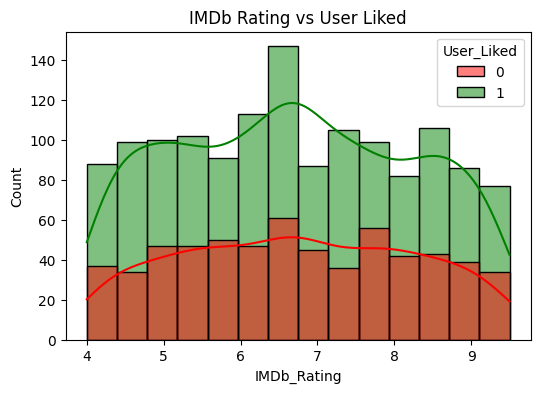

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="IMDb_Rating", hue="User_Liked",
             palette=["red","green"], kde=True)
plt.title("IMDb Rating vs User Liked")
plt.show()


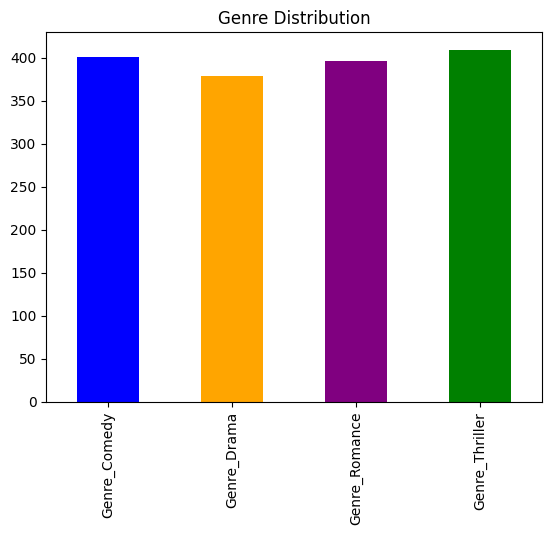

In [52]:
genre_cols = [col for col in df.columns if "Genre_" in col]

df[genre_cols].sum().plot(kind="bar", color=["blue","orange","purple","green"])
plt.title("Genre Distribution")
plt.show()


MACHINE LEARNING MODEL

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop("User_Liked", axis=1)
y = df["User_Liked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


SPLIT DATA

In [54]:
from sklearn.utils import resample

df_majority = df[df.User_Liked == 1]
df_minority = df[df.User_Liked == 0]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced["User_Liked"].value_counts()


,count
User_Liked,
1,1382
0,1382


FEATURE SCALING

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [57]:
df["User_Liked"] = ((df["IMDb_Rating"] >= 7.0) &
                    (df["Votes"] >= 15000)).astype(int)


In [58]:
from sklearn.utils import resample

major = df[df.User_Liked == 1]
minor = df[df.User_Liked == 0]

minor_up = resample(minor,
                    replace=True,
                    n_samples=len(major),
                    random_state=42)

df = pd.concat([major, minor_up])


Random Forest with Accuracy

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

accuracy_score(y_test, model.predict(X_test))


0.67

CONFUSION MATRIX

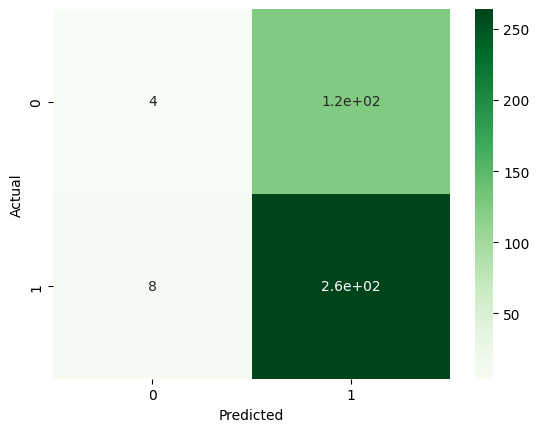

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
